# 설비 이상 장면 탐지 — VLM 기반 Anomaly Scene Detection (IPAD 실습)

** VLM 비디오 요약** 파이프라인을 확장하여, 산업 설비 영상에서 **이상 장면(anomaly scene)** 을 탐지합니다.

| Part | 주제 |
|------|------|
| 1 | IPAD 정상 baseline & 테스트 클립 — train/test 분리 |
| 2 | 프레임 단위 이상 신호 — Motion · Appearance 변화 |
| 3 | CLIP 임베딩 — 정상 baseline 대비 편차 점수 |
| 4 | VLM 쿼리 대조 — 정상 vs 이상 relevance |
| 5 | 시간 세그멘테이션 & 이상 장면 구간 탐지 |
| 6 | 통합 파이프라인 — 이상 장면 export + VLM 리포트 |

### IPAD 실습 데이터 (약 11 MB)

1. 노트북과 **같은 폴더**에 `IPAD_sample.zip` 배치
2. 실행 시 자동 압축 해제 → `IPAD_Sample/`
3. 구조: `{설비}/training/frames/{클립ID}/` (정상), `testing/` (이상 포함)


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **Motion Z-score** | 정상 대비 움직임 편차 | `compute_motion_zscore`, `score_motion_anomaly` |
| **Appearance Change** | 프레임 간 색상·구조 급변 | `compute_appearance_change`, `detect_shot_boundaries` |
| **CLIP Embedding Distance** | 정상 임베딩 centroid 거리 | `build_normal_baseline`, `score_embedding_anomaly` |
| **VLM Query Contrast** | 정상·이상 텍스트 쿼리 대조 | `score_anomaly_query_contrast` |
| **Change-Point Segmentation** | 의미 단위 구간 분할 | `segment_by_change_points` |
| **Fused Anomaly Score** | 다중 신호 가중 융합 | `fuse_anomaly_scores` |
| **Anomaly Scene Detection** | 구간·프레임 이상 후보 선별 | `detect_anomaly_scenes`, `adaptive_keyframe_sampling` |
| **VLM 리포트** | 이상 장면 키프레임 + 텍스트 | `run_anomaly_detection_pipeline`, BLIP (선택) |

핵심: 04번의 **선별·세그멘테이션·CLIP** 파이프라인을 **정상 baseline 대비 편차** 관점으로 재구성합니다.


In [1]:
# ── 패키지 설치 (최초 1회, 주석 해제 후 실행) ──
# requirements.txt: opencv, numpy, matplotlib, torch, transformers 등
# 노트북을 처음 열었을 때만 아래 pip 줄의 맨 앞 # 을 제거하고 실행하면 됩니다.
# !pip install -q -r requirements.txt
# !pip install scikit-image  # SSIM (선택 — 없으면 MSE fallback)


In [2]:
from __future__ import annotations

# =============================================================================
# 환경 설정 — import, IPAD/출력 경로, 이상 탐지 하이퍼파라미터, 한글 폰트
# =============================================================================

# --- 표준 라이브러리 ---
import json
import os
import platform
import subprocess
import textwrap
import zipfile
from dataclasses import dataclass, field
from pathlib import Path

# --- 영상·수치·시각화 ---
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
# --- 딥러닝 (CLIP/BLIP) ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.gridspec import GridSpec
from PIL import Image
from scipy import signal as sp_signal
from scipy.spatial.distance import cdist

# cdist: 프레임 간 거리 행렬 (고급 분석·확장용)

# scikit-image: SSIM 등 고급 유사도 (없어도 동작)
try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except ImportError:
    HAS_SKIMAGE = False

# ── 경로·모델 설정 ───────────────────────────────────────────────────────────
# zip 파일명 후보 (Windows 대소문자 차이 대응)
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_EXTRACT_DIR = Path("IPAD_Sample")
IPAD_SEARCH_PATHS = [IPAD_EXTRACT_DIR, Path("IPAD_sample"), Path("IPAD")]

# 탐지 결과 저장 루트 (그래프·프레임·JSON)
OUTPUT_DIR = Path("output_anomaly_scene")
FIG_DIR = OUTPUT_DIR / "figures"
ANOMALY_DIR = OUTPUT_DIR / "anomaly_frames"
SCENE_DIR = OUTPUT_DIR / "anomaly_scenes"
MANIFEST_PATH = OUTPUT_DIR / "anomaly_manifest.json"

# 분석 대상 설비/클립 (IPAD: R01, 클립 01)
SELECTED_DEVICE: str | None = "R01"
SELECTED_CLIP: str | None = "01"
SELECTED_TEST_CLIP: str | None = None
# 프레임→초 변환용 가정 FPS (IPAD 메타 없을 때 사용)
FPS_ASSUMED = 30.0

# 이상 탐지 파라미터 (테스트 클립에서 이상 구간이 눈에 띄도록 조정)
ANOMALY_Z_THRESHOLD = 1.5          # motion |Z| 경고선 (낮을수록 민감)
# change-point: HSV 히스토그램 Bhattacharyya 거리가 이 값 이상이면 장면 전환 후보
HIST_CHANGE_THRESHOLD = 0.20
# change-point: motion Z-score가 이 값 이상이면 장면 전환 후보
MOTION_Z_SEGMENT = 1.2
# 너무 짧은 구간은 노이즈로 간주 — 최소 이 길이(프레임) 이상일 때만 경계 인정
MIN_SEGMENT_LEN = 6
# AKS(adaptive keyframe sampling)로 뽑을 대표 이상 프레임 개수
NUM_ANOMALY_FRAMES = 8
# motion=움직임, appearance=색·조명, embedding=CLIP, query=텍스트 대조
FUSION_WEIGHTS = {"motion": 0.30, "appearance": 0.20, "embedding": 0.35, "query": 0.15}
ANOMALY_PERCENTILE = 80.0          # 융합 점수 상위 20% = 이상 후보
# change-point 구간 중 상위 몇 %를 이상 장면 후보로 볼지
SCENE_TOP_RATIO = 0.35
# 장면 후보로 채택되려면 구간 anomaly_score가 이 값 이상이어야 함
SCENE_MIN_SCORE = 0.40

# HuggingFace CLIP — 이미지·텍스트 공동 임베딩
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"
# CLIP/BLIP on/off (GPU 없으면 CLIP False로 histogram fallback)
RUN_CLIP = True
RUN_BLIP = False

# CLIP 텍스트 쿼리: 정상/이상 장면 설명 문장
NORMAL_QUERY = "normal industrial machine operation cycle"
ANOMALY_QUERY = "industrial machine malfunction abnormal vibration stuck error"

# CUDA 가능 시 GPU, 아니면 CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in (OUTPUT_DIR, FIG_DIR, ANOMALY_DIR, SCENE_DIR):
    d.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    """Google Colab 실행 여부 — Colab일 때만 나눔 폰트 apt 설치."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    # OS별 한글 폰트 후보를 순회하며 matplotlib rcParams에 적용
    """matplotlib 그래프 한글·마이너스 기호 깨짐 방지."""
    from matplotlib import font_manager
    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print(f"환경 설정 완료 | device={DEVICE} | skimage={HAS_SKIMAGE}")


환경 설정 완료 | device=cuda | skimage=True


In [3]:
# =============================================================================
# IPAD 데이터 로드 · 프레임 I/O · Motion/Appearance 기초 특징
# =============================================================================
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}  # IPAD 프레임 확장자


@dataclass
class IpadClip:
    """IPAD 클립 1개 = 설비 / split / clip_id / 프레임 경로 목록."""
    device: str
    split: str
    clip_id: str
    frame_dir: Path
    frame_paths: list[Path]

    @property
    def num_frames(self) -> int:
        return len(self.frame_paths)


def _list_frame_files(frame_dir: Path) -> list[Path]:
    """클립 폴더에서 jpg/png 등 프레임 파일 경로를 정렬해 반환."""
    files = [p for p in frame_dir.iterdir() if p.suffix.lower() in FRAME_EXTS]
    return sorted(files, key=lambda p: p.name)


def _search_roots() -> list[Path]:
    """zip/IPAD 탐색 후보: cwd + VS Code/Cursor 노트북 폴더."""
    roots: list[Path] = [Path.cwd().resolve()]
    try:
        from IPython import get_ipython
        ip = get_ipython()
        nb_file = ip.user_ns.get("__vsc_ipynb_file__") if ip else None
        if nb_file:
            nb_dir = Path(nb_file).resolve().parent
            if nb_dir not in roots:
                roots.insert(0, nb_dir)
    except Exception:
        pass
    return roots


def _is_valid_ipad_root(base: Path) -> bool:
    """{설비}/training/frames 구조 존재 여부 (폴더만, 파일 무관)."""
    if not base.is_dir():
        return False
    for child in base.iterdir():
        if child.is_dir() and (child / "training" / "frames").is_dir():
            return True
    return (base / "training" / "frames").is_dir()


def _ipad_root_has_clips(base: Path) -> bool:
    """폴더 구조뿐 아니라 실제 프레임(.jpg 등) 존재 여부까지 확인."""
    if not _is_valid_ipad_root(base):
        return False
    for dev in sorted(d for d in base.iterdir() if d.is_dir()):
        for split in ("training", "testing"):
            frames_root = dev / split / "frames"
            if not frames_root.is_dir():
                continue
            for clip_dir in frames_root.iterdir():
                if clip_dir.is_dir() and _list_frame_files(clip_dir):
                    return True
    train_frames = base / "training" / "frames"
    if train_frames.is_dir():
        for clip_dir in train_frames.iterdir():
            if clip_dir.is_dir() and _list_frame_files(clip_dir):
                return True
    return False


def find_ipad_zip() -> Path | None:
    """노트북 폴더·cwd에서 IPAD_Sample.zip 탐색."""
    for root in _search_roots():
        for name in IPAD_ZIP_NAMES:
            p = root / name
            if p.is_file():
                return p
        try:
            for f in root.iterdir():
                if f.is_file() and f.suffix.lower() == ".zip" and f.stem.lower() == "ipad_sample":
                    return f
        except OSError:
            continue
    return None


def ensure_ipad_sample() -> Path | None:
    """zip 압축 해제 또는 기존 IPAD_Sample 사용. 프레임 없으면 재추출."""
    # 1) 프레임이 실제로 있는 데이터셋이면 그대로 사용
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if _ipad_root_has_clips(base):
                return base

    # 2) 구조만 있고 프레임이 없으면 → zip 재추출 시도
    zpath = find_ipad_zip()
    if zpath is None:
        return None

    extract_to = zpath.parent
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if _is_valid_ipad_root(base) and not _ipad_root_has_clips(base):
                print(f"[IPAD] 프레임 없음 → 재추출: {base.resolve()}")

    print(f"[IPAD] {zpath.name} 압축 해제 중 -> {extract_to}")
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(extract_to)

    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if _ipad_root_has_clips(base):
                print(f"[IPAD] 데이터 준비 완료: {base.resolve()}")
                return base
    return None


def find_ipad_root() -> Path | None:
    """유효한 IPAD 데이터셋 루트 경로 반환."""
    ensure_ipad_sample()
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if not base.exists():
                continue
            if _ipad_root_has_clips(base):
                return base
            if (base / "training" / "frames").is_dir() and _ipad_root_has_clips(base):
                return base.parent
    return None


def discover_clips(root: Path) -> list[IpadClip]:
    """루트 아래 모든 training/testing 클립을 IpadClip 리스트로 수집."""
    # IPAD 구조: {설비}/{training|testing}/frames/{clip_id}/*.jpg
    clips: list[IpadClip] = []
    devices = sorted(d for d in root.iterdir() if d.is_dir())
    for dev in devices:
        for split in ("training", "testing"):
            frames_root = dev / split / "frames"
            if not frames_root.is_dir():
                continue
            for clip_dir in sorted(d for d in frames_root.iterdir() if d.is_dir()):
                paths = _list_frame_files(clip_dir)
                if paths:
                    clips.append(IpadClip(dev.name, split, clip_dir.name, clip_dir, paths))
    return clips


def try_load_anomaly_labels(root: Path, device: str) -> np.ndarray | None:
    """IPAD frame_labels_{device}.npy — 0=정상, 1=이상."""
    # IPAD GT: frame_labels_{설비}.npy — 0=정상, 1=이상 (없으면 None)
    candidates = list(root.rglob(f"frame_labels_{device}.npy"))
    candidates += list(root.rglob("frame_labels_*.npy"))
    for p in candidates:
        try:
            labels = np.load(p, allow_pickle=True)
            print(f"[라벨] 로드: {p}")
            return labels
        except Exception:
            continue
    return None


def resolve_anomaly_session(
    device: str | None = None,
    clip_id: str | None = None,
) -> tuple[Path, IpadClip, IpadClip | None]:
    """정상 training 클립 + testing 클립(있으면) 반환."""
    root = find_ipad_root()
    if root is None:
        z = find_ipad_zip()
        roots = ", ".join(str(r) for r in _search_roots())
        raise FileNotFoundError(
            "IPAD 데이터를 찾을 수 없습니다.\n"
            "  1) 노트북과 같은 폴더에 IPAD_Sample.zip 배치\n"
            "  2) 설정 셀(Cell 3~4)부터 다시 실행\n"
            f"  탐색 경로: {roots}\n"
            f"  zip 발견: {z or '없음'}"
        )
    clips = discover_clips(root)
    if not clips:
        z = find_ipad_zip()
        raise FileNotFoundError(
            f"클립 없음: {root}\n"
            "  IPAD_Sample 폴더는 있지만 프레임 이미지(.jpg)가 없습니다.\n"
            "  → IPAD_Sample 폴더를 삭제한 뒤, IPAD_Sample.zip과 함께\n"
            "     설정 셀부터 다시 실행하면 자동으로 재추출됩니다.\n"
            f"  zip: {z or 'IPAD_Sample.zip 을 찾을 수 없음'}"
        )

    # SELECTED_DEVICE/CLIP으로 training 풀 필터 → 첫 클립을 정상 baseline으로 사용
    dev = device or SELECTED_DEVICE
    cid = clip_id or SELECTED_CLIP
    train_pool = [c for c in clips if c.split == "training"]
    if dev:
        train_pool = [c for c in train_pool if c.device == dev] or train_pool
    if cid:
        train_pool = [c for c in train_pool if c.clip_id == cid] or train_pool
    train_pool = sorted(train_pool, key=lambda c: (c.device, c.clip_id))
    train_clip = train_pool[0]

    test_pool = [c for c in clips if c.split == "testing" and c.device == train_clip.device]
    test_clip = None
    if test_pool:
        tid = SELECTED_TEST_CLIP or test_pool[0].clip_id
        test_pool = [c for c in test_pool if c.clip_id == tid] or test_pool
        test_clip = sorted(test_pool, key=lambda c: c.clip_id)[0]
    return root, train_clip, test_clip


def imread_bgr(path: Path) -> np.ndarray | None:
    """Windows 한글 경로에서도 동작하는 BGR 이미지 로드."""
    # cv2.imread는 Windows 한글 경로에서 실패할 수 있음 → 아래 fallback 사용
    img = cv2.imread(str(path))
    if img is not None:
        return img
    try:
        buf = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(buf, cv2.IMREAD_COLOR)
    except Exception:
        return None


def imwrite_bgr(path: Path, image: np.ndarray) -> bool:
    """Windows 한글 경로에서도 동작하는 BGR 이미지 저장."""
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, enc = cv2.imencode(path.suffix or ".jpg", image)
    if not ok:
        return False
    try:
        enc.tofile(str(path))
        return True
    except Exception:
        return cv2.imwrite(str(path), image)


def load_clip_frames(clip: IpadClip, max_frames: int | None = None) -> list[np.ndarray]:
    """IpadClip의 프레임 경로 → BGR numpy 배열 리스트."""
    paths = clip.frame_paths if max_frames is None else clip.frame_paths[:max_frames]
    frames = []
    for p in paths:
        img = imread_bgr(p)
        if img is not None:
            frames.append(img)
    if paths and not frames:
        print(f"[경고] 프레임 {len(paths)}개 경로는 있으나 이미지 로드 실패: {paths[0].parent}")
    return frames


def frame_to_rgb(frame_bgr: np.ndarray) -> np.ndarray:
    """OpenCV BGR → matplotlib/PIL용 RGB."""
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def compute_motion_energy(frames: list[np.ndarray]) -> np.ndarray:
    """연속 그레이스케일 프레임 차이 평균 — Motion Energy (길이 N-1)."""
    # 인접 프레임 그레이스케일 absdiff 평균 → 프레임당 1개 motion 값
    energy = []
    for i in range(len(frames) - 1):
        g1 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g2 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        energy.append(float(np.mean(cv2.absdiff(g1, g2))))
    return np.asarray(energy, dtype=np.float32)


def compute_color_histogram(frame_bgr: np.ndarray, bins: int = 32) -> np.ndarray:
    """HSV 2D 히스토그램 — 장면/조명 변화(Appearance) 감지용."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1], None, [bins, bins], [0, 180, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


def histogram_distance(h1: np.ndarray, h2: np.ndarray) -> float:
    """Bhattacharyya 거리 — 0에 가까울수록 두 히스토그램 유사."""
    return float(cv2.compareHist(h1.astype(np.float32), h2.astype(np.float32), cv2.HISTCMP_BHATTACHARYYA))


## Part 1 — IPAD 정상 baseline & 테스트 클립

In [4]:
# ── IPAD train/test 클립 로드 ──
# training = 정상 baseline, testing = 이상 포함 분석 대상
# resolve_anomaly_session: zip/폴더 탐색 → 정상 training 클립 + testing 클립(있으면) 선택
IPAD_ROOT, TRAIN_CLIP, TEST_CLIP = resolve_anomaly_session(SELECTED_DEVICE, SELECTED_CLIP)
TRAIN_FRAMES = load_clip_frames(TRAIN_CLIP)  # 정상 프레임 이미지 배열
TRAIN_MOTION = compute_motion_energy(TRAIN_FRAMES)  # N-1 길이 motion energy 시계열

TARGET_CLIP = TEST_CLIP or TRAIN_CLIP  # testing 없으면 training으로 unsupervised
TARGET_FRAMES = load_clip_frames(TARGET_CLIP)
TARGET_MOTION = compute_motion_energy(TARGET_FRAMES)
# GT 라벨(npy) — 있으면 그래프에 GT 음영, 없어도 탐지 가능
FRAME_LABELS = try_load_anomaly_labels(IPAD_ROOT, TRAIN_CLIP.device)

print(f"IPAD root : {IPAD_ROOT}")
print(f"정상 클립 : {TRAIN_CLIP.device}/{TRAIN_CLIP.split}/{TRAIN_CLIP.clip_id} "
      f"({len(TRAIN_FRAMES)} frames, 경로상 {TRAIN_CLIP.num_frames}장)")
if TEST_CLIP:
    print(f"테스트 클립: {TEST_CLIP.device}/{TEST_CLIP.split}/{TEST_CLIP.clip_id} "
          f"({len(TARGET_FRAMES)} frames, 경로상 {TEST_CLIP.num_frames}장)")
else:
    print("테스트 클립 없음 — training 클립으로 unsupervised 이상 탐지 데모")
if len(TRAIN_FRAMES) == 0:
    raise RuntimeError(
        "프레임 이미지를 읽지 못했습니다 (label 폴더와 무관).\n"
        "  → Kernel 재시작 후 Cell 3~6을 다시 실행하세요."
    )
print(f"Motion baseline (train mean): {TRAIN_MOTION.mean():.4f} ± {TRAIN_MOTION.std():.4f}")


IPAD root : C:\MyCursorLab\08_Video AI 처리 및 분석\IPAD_Sample
정상 클립 : R01/training/01 (207 frames, 경로상 207장)
테스트 클립: R01/testing/01 (230 frames, 경로상 230장)
Motion baseline (train mean): 1.5453 ± 0.1667


> **📖 Part 1 결과 해석 (초보자용)**
>
> IPAD 데이터셋은 **training**(정상)과 **testing**(이상 포함) 폴더로 나뉩니다.
>
> | 출력 | 의미 |
> |------|------|
> | **정상 클립** | `R01/training/frames/01` — "이렇게 움직이면 정상"이라고 학습하는 기준 |
> | **테스트 클립** | `R01/testing/frames/...` — 이상이 섞인 영상, 우리가 찾을 대상 |
> | **Motion baseline** | 정상 클립 움직임의 평균·표준편차 — 이후 "얼마나 다른지" 비교에 사용 |
>
> 💡 testing 클립이 없으면 training 클립으로 **비지도(unsupervised)** 데모를 실행합니다.


## Part 2 — 프레임 단위 이상 신호 (Motion · Appearance)

정상 training 클립의 **motion 분포**를 baseline으로 두고, 테스트 프레임의 편차를 Z-score로 측정합니다.
Appearance change는 연속 프레임 히스토그램 거리로 **장면 급변**을 포착합니다.


In [5]:
# =============================================================================
# 프레임 단위 이상 신호 — Motion Z-score · Appearance · reference 대비 점수
# =============================================================================

def compute_motion_zscore(motion: np.ndarray, ref_mean: float, ref_std: float) -> np.ndarray:
    """정상 baseline 대비 motion Z-score (길이 = len(motion))."""
    # motion[i]는 frame i→i+1 차이이므로 앞에 0 패딩해 프레임 인덱스와 길이 맞춤
    padded = np.concatenate([[0.0], motion]) if len(motion) else np.zeros(1)
    return (padded - ref_mean) / (ref_std + 1e-6)


def compute_appearance_change(frames: list[np.ndarray]) -> np.ndarray:
    """연속 프레임 BHATTACHARYYA 거리 — appearance 급변 신호."""
    if len(frames) < 2:
        return np.zeros(len(frames), dtype=np.float32)
    hists = [compute_color_histogram(f) for f in frames]
    diff = [0.0]
    for i in range(1, len(hists)):
        diff.append(histogram_distance(hists[i], hists[i - 1]))
    return np.asarray(diff, dtype=np.float32)


def normalize_score(scores: np.ndarray) -> np.ndarray:
    """min-max로 0~1 정규화 (클립 내 상대 점수)."""
    s = scores.astype(np.float32)
    return (s - s.min()) / (s.max() - s.min() + 1e-6)


def score_against_reference(target: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """정상(reference) 분포 대비 편차 → 0~1 이상 점수 (클수록 이상)."""
    mu = float(reference.mean())
    sigma = float(reference.std()) + 1e-6
    z = np.abs((target.astype(np.float32) - mu) / sigma)
    # sigmoid로 0~1 매핑 — Z=2 근처에서 급격히 상승
    return (1.0 / (1.0 + np.exp(-0.8 * (z - 1.5)))).astype(np.float32)


def score_motion_anomaly(motion: np.ndarray, ref_motion: np.ndarray) -> np.ndarray:
    """정상 ref_motion 분포 대비 |Z| → 0~1 motion 이상 점수."""
    mu, sigma = float(ref_motion.mean()), float(ref_motion.std()) + 1e-6
    z = compute_motion_zscore(motion, mu, sigma)
    abs_z = np.abs(z)
    ref_z = np.abs((np.concatenate([[0.0], ref_motion]) - mu) / sigma)
    return score_against_reference(abs_z, ref_z)


# --- 정상 baseline 통계 & 테스트 클립 4종 신호 계산 ---
TRAIN_MU, TRAIN_SIGMA = float(TRAIN_MOTION.mean()), float(TRAIN_MOTION.std()) + 1e-6
TRAIN_APPEARANCE = compute_appearance_change(TRAIN_FRAMES)

# 아래 2종은 testing 클립에 대해 training 분포 대비 0~1 이상 점수
MOTION_ANOMALY = score_motion_anomaly(TARGET_MOTION, TRAIN_MOTION)
APPEARANCE_RAW = compute_appearance_change(TARGET_FRAMES)
APPEARANCE_ANOMALY = score_against_reference(APPEARANCE_RAW, TRAIN_APPEARANCE)

# 0.55는 시각화용 경고선 — 융합 임계값(FUSED_THRESHOLD)과 별개
motion_flags = np.where(MOTION_ANOMALY >= 0.55)[0]
print(f"Motion 이상 후보 (score≥0.55): {len(motion_flags)} frames")
print(f"Appearance change peak frame: #{int(np.argmax(APPEARANCE_RAW))}")
print(f"  → 정상 baseline 대비 편차 점수: {APPEARANCE_ANOMALY[int(np.argmax(APPEARANCE_RAW))]:.3f}")


Motion 이상 후보 (score≥0.55): 5 frames
Appearance change peak frame: #12
  → 정상 baseline 대비 편차 점수: 0.860


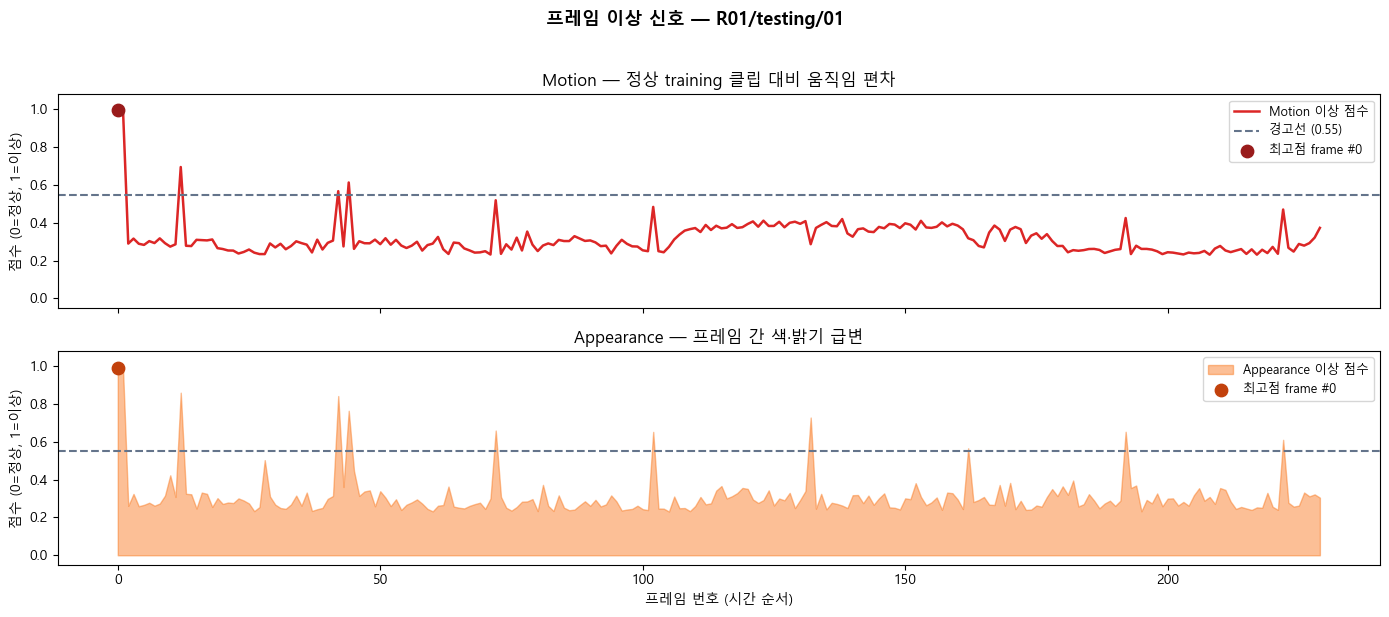

In [6]:
# --- 프레임 이상 신호 시각화 (Motion · Appearance 곡선) ---

def _shade_gt(axes, labels: np.ndarray | None, n: int, color: str = "#fecaca") -> None:
    """GT 라벨=1 구간을 연한 빨간 음영으로 표시 (frame_labels_*.npy, 있을 때만)."""
    if labels is None or len(labels) < n:
        return
    gt = labels[:n]
    in_anomaly = False
    start = 0
    # GT=1 구간의 시작·끝을 찾아 axvspan으로 음영 처리
    for i, v in enumerate(gt):
        if v > 0 and not in_anomaly:
            start, in_anomaly = i, True
        elif v <= 0 and in_anomaly:
            for ax in axes:
                ax.axvspan(start - 0.5, i - 0.5, color=color, alpha=0.35, zorder=0)
            in_anomaly = False
    if in_anomaly:
        for ax in axes:
            ax.axvspan(start - 0.5, n - 0.5, color=color, alpha=0.35, zorder=0)


def plot_frame_anomaly_signals(
    motion_anomaly: np.ndarray,
    appearance_anomaly: np.ndarray,
    labels: np.ndarray | None,
    z_threshold: float,
    title: str,
    save_path: Path,
) -> None:
    """프레임별 Motion·Appearance 이상 점수를 2행 subplot으로 그린다."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    x = np.arange(len(motion_anomaly))
    warn = 0.55  # 경고선: 이 점수 이상이면 이상 후보

    _shade_gt(axes, labels, len(motion_anomaly))

    axes[0].plot(x, motion_anomaly, color="#dc2626", lw=1.8, label="Motion 이상 점수")
    axes[0].axhline(warn, color="#64748b", ls="--", lw=1.5, label=f"경고선 ({warn})")
    # motion 곡선에서 최고점 프레임을 scatter로 강조
    peak_m = int(np.argmax(motion_anomaly))
    axes[0].scatter([peak_m], [motion_anomaly[peak_m]], color="#991b1b", s=80, zorder=5,
                    label=f"최고점 frame #{peak_m}")
    axes[0].set_ylabel("점수 (0=정상, 1=이상)")
    axes[0].set_ylim(-0.05, 1.08)
    axes[0].legend(loc="upper right", fontsize=9)
    axes[0].set_title("Motion — 정상 training 클립 대비 움직임 편차")

    axes[1].fill_between(x, appearance_anomaly, alpha=0.45, color="#f97316", label="Appearance 이상 점수")
    axes[1].axhline(warn, color="#64748b", ls="--", lw=1.5)
    peak_a = int(np.argmax(appearance_anomaly))
    axes[1].scatter([peak_a], [appearance_anomaly[peak_a]], color="#c2410c", s=80, zorder=5,
                    label=f"최고점 frame #{peak_a}")
    axes[1].set_xlabel("프레임 번호 (시간 순서)")
    axes[1].set_ylabel("점수 (0=정상, 1=이상)")
    axes[1].set_ylim(-0.05, 1.08)
    axes[1].legend(loc="upper right", fontsize=9)
    axes[1].set_title("Appearance — 프레임 간 색·밝기 급변")

    if labels is not None:
        fig.text(0.5, 0.01, "연한 빨간 음영 = GT 이상 라벨 (frame_labels_*.npy, 있을 때)",
                 ha="center", fontsize=9, color="#991b1b")

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


# Motion·Appearance 이상 곡선 PNG 저장
plot_frame_anomaly_signals(
    MOTION_ANOMALY,
    APPEARANCE_ANOMALY,
    FRAME_LABELS,
    ANOMALY_Z_THRESHOLD,
    f"프레임 이상 신호 — {TARGET_CLIP.device}/{TARGET_CLIP.split}/{TARGET_CLIP.clip_id}",
    FIG_DIR / "01_frame_anomaly_signals.png",
)


> **📖 Part 2 결과 해석 (초보자용)**
>
> | 그래프 | 읽는 법 |
> |--------|---------|
> | **Motion (빨간 선)** | 설비 움직임이 **정상 클립과 얼마나 다른지**를 0~1 점수로 표시합니다. 선이 **경고선(0.55) 위**로 올라가면 움직임 이상 후보입니다. |
> | **Appearance (주황 영역)** | 연속 프레임 사이 **색·밝기 변화**가 클수록 점수가 높아집니다. 카메라 전환·조명 변화·설비 상태 변화를 잡습니다. |
> | **빨간 음영** | IPAD GT 라벨(`frame_labels_*.npy`, **선택**)이 있으면 실제 이상 구간을 표시합니다. **없어도 탐지는 정상 동작**합니다. |
>
> 💡 **핵심**: 두 신호 중 **하나라도 경고선을 넘는 구간**을 주목하세요. 이후 Part 5에서 네 가지 신호를 합쳐 최종 판정합니다.


## Part 3 — CLIP 임베딩 baseline & 편차 점수

04번 `encode_frames_clip`으로 프레임 임베딩을 추출하고, **정상 training centroid** 와의 cosine distance를 이상 점수로 사용합니다.


In [7]:
# =============================================================================
# CLIP 임베딩 — 정상 centroid 대비 cosine distance
# =============================================================================

# CLIP 모델은 용량이 크므로 최초 호출 시 1회만 로드 (lazy load)
_clip_model = None
_clip_processor = None


def get_clip_model():
    """CLIP 모델·프로세서 lazy load (1회만 GPU에 올림)."""
    global _clip_model, _clip_processor
    if _clip_model is None and RUN_CLIP:
        from transformers import CLIPModel, CLIPProcessor
        _clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(DEVICE).eval()
    return _clip_model, _clip_processor


def _as_feature_tensor(output) -> torch.Tensor:
    """transformers CLIP 출력에서 텐서 추출 (버전별 API 차이 흡수)."""
    if isinstance(output, torch.Tensor):
        return output
    for attr in ("image_embeds", "text_embeds", "pooler_output"):
        val = getattr(output, attr, None)
        if val is not None:
            return val
    raise TypeError(f"Unexpected CLIP output type: {type(output)}")


@torch.inference_mode()
def encode_frames_clip(frames: list[np.ndarray], batch_size: int = 16) -> np.ndarray:
    """프레임 배치 → L2 정규화 CLIP image embedding (N×512)."""
    model, processor = get_clip_model()
    if model is None:
        feats = [compute_color_histogram(f, bins=16) for f in frames]
        return np.stack(feats)
    all_emb = []
    for i in range(0, len(frames), batch_size):
        batch = frames[i : i + batch_size]
        images = [Image.fromarray(frame_to_rgb(f)) for f in batch]
        inputs = processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
        emb = _as_feature_tensor(model.get_image_features(**inputs))
        emb = F.normalize(emb, dim=-1)
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


def build_normal_baseline(train_frames: list[np.ndarray]) -> np.ndarray:
    """정상 CLIP 임베딩 centroid (L2 normalized)."""
    emb = encode_frames_clip(train_frames)
    centroid = emb.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-6)
    return centroid.astype(np.float32)


def score_embedding_anomaly(frames: list[np.ndarray], centroid: np.ndarray,
                            ref_frames: list[np.ndarray] | None = None) -> np.ndarray:
    """centroid와 cosine distance — 정상 대비 편차를 0~1로 변환."""
    emb = encode_frames_clip(frames)
    sim = emb @ centroid
    dist = 1.0 - sim
    if ref_frames:
        ref_dist = 1.0 - (encode_frames_clip(ref_frames) @ centroid)
        return score_against_reference(dist.astype(np.float32), ref_dist.astype(np.float32))
    return normalize_score(dist.astype(np.float32))


# 정상 training centroid 구축 후 testing 편차 점수
# training 임베딩 평균 = '정상' 의미 공간의 중심(centroid)
NORMAL_CENTROID = build_normal_baseline(TRAIN_FRAMES)
EMBEDDING_ANOMALY = score_embedding_anomaly(TARGET_FRAMES, NORMAL_CENTROID, TRAIN_FRAMES)
print(f"CLIP embedding dim: {NORMAL_CENTROID.shape[0]}")
top5 = np.argsort(EMBEDDING_ANOMALY)[-5:][::-1].tolist()
print(f"Embedding 이상 Top-5 프레임: {top5}")
for idx in top5[:3]:
    print(f"  frame #{idx}: score={EMBEDDING_ANOMALY[idx]:.3f}")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP embedding dim: 512
Embedding 이상 Top-5 프레임: [157, 62, 134, 226, 170]
  frame #157: score=1.000
  frame #62: score=1.000
  frame #134: score=1.000


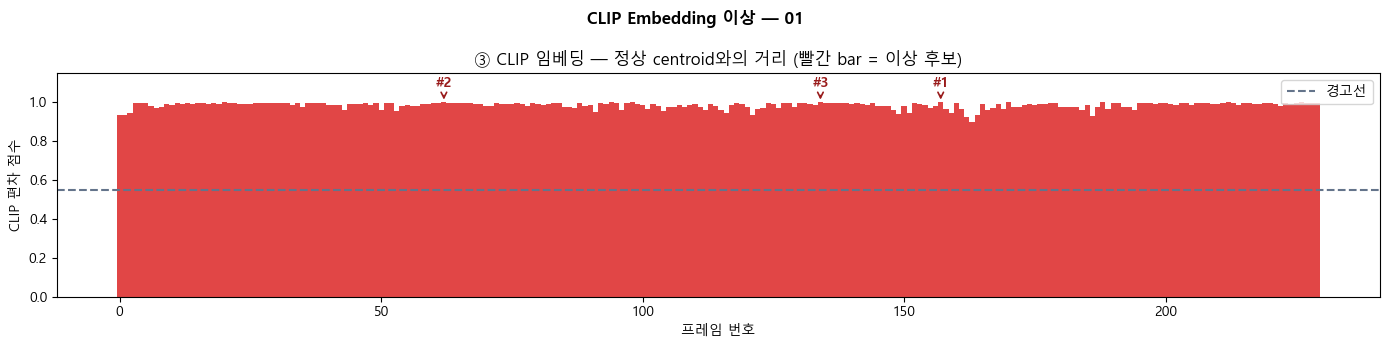

In [8]:
# CLIP embedding 이상 bar chart
def plot_embedding_anomaly(embedding_scores: np.ndarray, labels: np.ndarray | None,
                           title: str, save_path: Path) -> None:
    """정상 centroid 대비 CLIP 편차 점수를 프레임별 bar chart로 표시."""
def plot_embedding_anomaly(embedding_scores: np.ndarray, labels: np.ndarray | None,
                           title: str, save_path: Path) -> None:
    """정상 centroid 대비 CLIP 편차 점수를 프레임별 bar chart로 표시."""
def plot_embedding_anomaly(embedding_scores: np.ndarray, labels: np.ndarray | None,
                           title: str, save_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(14, 3.5))
    x = np.arange(len(embedding_scores))
    colors = np.where(embedding_scores >= 0.55, "#dc2626", "#94a3b8")  # 빨강=경고선 이상
    ax.bar(x, embedding_scores, color=colors, width=1.0, alpha=0.85)
    ax.axhline(0.55, color="#64748b", ls="--", label="경고선")
    # GT 라벨이 있으면 세로선으로 표시 (frame_labels_*.npy)
    if labels is not None and len(labels) >= len(embedding_scores):
        for i in np.where(labels[:len(embedding_scores)] > 0)[0]:
            ax.axvline(i, color="#991b1b", alpha=0.25, lw=2)
    top3 = np.argsort(embedding_scores)[-3:][::-1]
    for rank, idx in enumerate(top3, 1):
        ax.annotate(f"#{rank}", xy=(idx, embedding_scores[idx]),
                    xytext=(idx, embedding_scores[idx] + 0.08),
                    ha="center", fontsize=10, fontweight="bold", color="#991b1b",
                    arrowprops=dict(arrowstyle="->", color="#991b1b", lw=1.2))
    ax.set_xlabel("프레임 번호")
    ax.set_ylabel("CLIP 편차 점수")
    ax.set_ylim(0, 1.15)
    ax.set_title("③ CLIP 임베딩 — 정상 centroid와의 거리 (빨간 bar = 이상 후보)")
    ax.legend(loc="upper right")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


plot_embedding_anomaly(
    EMBEDDING_ANOMALY, FRAME_LABELS,
    f"CLIP Embedding 이상 — {TARGET_CLIP.clip_id}",
    FIG_DIR / "01b_embedding_anomaly.png",
)


> **📖 Part 3 결과 해석 (초보자용)**
>
> **CLIP**은 이미지를 512차원 벡터(임베딩)로 바꿉니다. 정상 training 프레임들의 **평균 벡터(centroid)** 를 만들고, 각 테스트 프레임이 그 중심에서 **얼마나 멀리 있는지** 측정합니다.
>
> - **회색 bar**: 정상에 가까운 프레임  
> - **빨간 bar**: 정상과 시각적으로 다른 프레임 (이상 후보)  
> - **#1, #2, #3** 표시: 가장 이상 점수가 높은 상위 3프레임
>
> 💡 Motion/Appearance는 **픽셀·움직임** 기준이고, CLIP은 **의미·장면** 기준입니다. 서로 다른 관점이라 함께 쓰면 탐지가 더 정확해집니다.


## Part 4 — VLM 쿼리 대조 (정상 vs 이상 relevance)

04번 `score_frames_with_clip`을 확장하여 **이상 쿼리 − 정상 쿼리** contrast score를 계산합니다.


Query contrast Top-5 frames: [132, 79, 76, 78, 169]
  정상 쿼리 : 'normal industrial machine operation cycle'
  이상 쿼리 : 'industrial machine malfunction abnormal vibration stuck error'


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30132\2107438437.py:62: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30132\2107438437.py:63: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.savefig(save_path, dpi=140, bbox_inches="tight")
C:\Users\storm\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


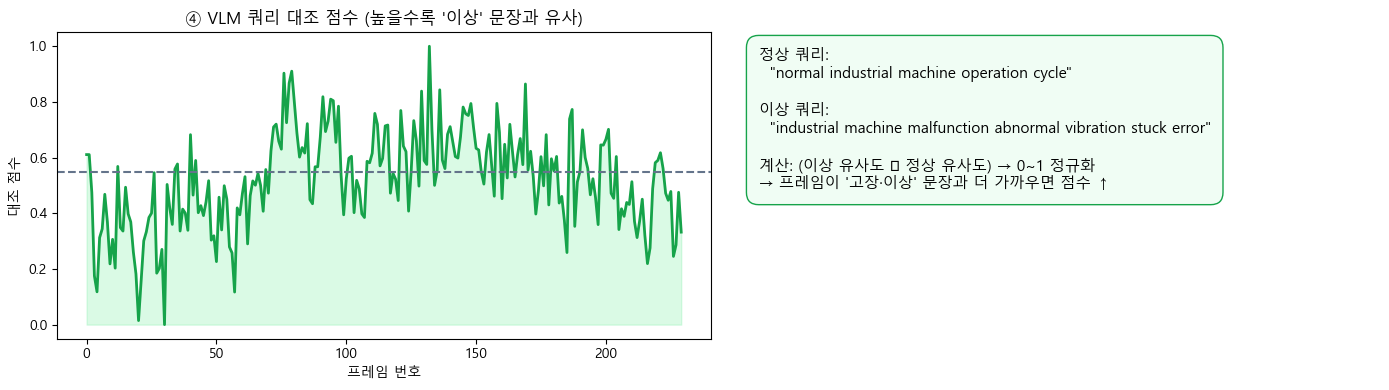

In [9]:
# =============================================================================
# VLM 쿼리 대조 — 정상 vs 이상 텍스트 relevance 차이
# =============================================================================

@torch.inference_mode()
def score_frames_with_clip(frames: list[np.ndarray], text_query: str) -> np.ndarray:
    """각 프레임과 text_query의 CLIP cosine similarity (raw, 미정규화)."""
    model, processor = get_clip_model()
    img_emb = encode_frames_clip(frames)
    if model is None:
        return np.linspace(0.3, 1.0, len(frames))
    inputs = processor(text=[text_query], return_tensors="pt", padding=True).to(DEVICE)
    txt_emb = _as_feature_tensor(model.get_text_features(**inputs))
    txt_emb = F.normalize(txt_emb, dim=-1).cpu().numpy()
    # image·text embedding 내적 = cosine similarity (둘 다 L2 정규화됨)
    scores = (img_emb @ txt_emb.T).squeeze(-1)
    return scores.astype(np.float32)


def score_anomaly_query_contrast(
    frames: list[np.ndarray],
    normal_query: str = NORMAL_QUERY,
    anomaly_query: str = ANOMALY_QUERY,
) -> np.ndarray:
    """anomaly relevance − normal relevance — 양수·클수록 이상 의미에 가까움."""
    if not RUN_CLIP:
        return normalize_score(compute_motion_energy(frames))
    normal_scores = score_frames_with_clip(frames, normal_query)
    anomaly_scores = score_frames_with_clip(frames, anomaly_query)
    # '고장/이상' 문장 유사도에서 '정상' 유사도를 빼면 의미 대조 점수
    contrast = anomaly_scores - normal_scores
    return normalize_score(contrast.astype(np.float32))


QUERY_ANOMALY = score_anomaly_query_contrast(TARGET_FRAMES)
print(f"Query contrast Top-5 frames: {np.argsort(QUERY_ANOMALY)[-5:][::-1].tolist()}")
print(f"  정상 쿼리 : '{NORMAL_QUERY}'")
print(f"  이상 쿼리 : '{ANOMALY_QUERY}'")


def plot_query_contrast(normal_q: str, anomaly_q: str, query_scores: np.ndarray,
                        save_path: Path) -> None:
    """VLM 쿼리 대조 곡선 + 사용한 정상/이상 문장 설명 패널."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = np.arange(len(query_scores))
    axes[0].plot(x, query_scores, color="#16a34a", lw=2)
    axes[0].fill_between(x, query_scores, alpha=0.3, color="#86efac")
    axes[0].axhline(0.55, color="#64748b", ls="--")
    axes[0].set_title("④ VLM 쿼리 대조 점수 (높을수록 '이상' 문장과 유사)")
    axes[0].set_xlabel("프레임 번호")
    axes[0].set_ylabel("대조 점수")

    axes[1].axis("off")
    text = (
        f'정상 쿼리:\n  "{normal_q}"\n\n'
        f'이상 쿼리:\n  "{anomaly_q}"\n\n'
        "계산: (이상 유사도 − 정상 유사도) → 0~1 정규화\n"
        "→ 프레임이 '고장·이상' 문장과 더 가까우면 점수 ↑"
    )
    axes[1].text(0.05, 0.95, text, va="top", fontsize=11,
                 bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0fdf4", edgecolor="#16a34a"))
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


plot_query_contrast(NORMAL_QUERY, ANOMALY_QUERY, QUERY_ANOMALY, FIG_DIR / "01c_query_contrast.png")


> **📖 Part 4 결과 해석 (초보자용)**
>
> CLIP은 **텍스트와 이미지**도 같은 공간에 놓을 수 있습니다.  
> - **정상 쿼리**: "normal industrial machine operation cycle"  
> - **이상 쿼리**: "malfunction abnormal vibration stuck error"
>
> 각 프레임에 두 문장의 **유사도 차이**를 계산합니다. 그래프가 **0.55 위**이면 "이 프레임은 고장·이상 장면처럼 보인다"는 뜻입니다.


## Part 5 — 시간 세그멘테이션 & 이상 장면 구간 탐지

Change-point 세그멘테이션 + **다중 신호 융합 점수**로 이상 장면 구간을 탐지합니다.


In [10]:
# =============================================================================
# 시간 세그멘테이션 · 4신호 융합 · 이상 장면/프레임 탐지
# =============================================================================

@dataclass
class VideoSegment:
    """change-point로 나눈 연속 프레임 구간 + 구간 이상 점수."""
    start: int
    end: int
    importance: float = 0.0
    anomaly_score: float = 0.0

    @property
    def length(self) -> int:
        return self.end - self.start


def segments_from_boundaries(boundaries: list[int], total: int) -> list[VideoSegment]:
    """경계 인덱스 리스트 → [start,end) VideoSegment 목록."""
    bounds = sorted(set(boundaries + [total]))
    return [VideoSegment(s, e) for s, e in zip(bounds[:-1], bounds[1:]) if e - s >= 1]


def segment_by_change_points(
    frames: list[np.ndarray],
    motion: np.ndarray,
    hist_threshold: float = HIST_CHANGE_THRESHOLD,
    motion_z: float = MOTION_Z_SEGMENT,
) -> list[VideoSegment]:
    hists = [compute_color_histogram(f) for f in frames]
    hist_diff = np.array([
        histogram_distance(hists[i], hists[i - 1]) if i > 0 else 0.0
        for i in range(len(hists))
    ])
    motion_padded = np.concatenate([[0.0], motion]) if len(motion) else np.zeros(len(frames))
    mu, sigma = motion_padded.mean(), motion_padded.std() + 1e-6
    motion_zscore = (motion_padded - mu) / sigma

    boundaries = [0]  # 장면 전환 후보 프레임 인덱스
    # 히스토그램 급변 또는 motion Z-score가 임계값 초과 → 새 구간 시작
    for i in range(1, len(frames)):
        if hist_diff[i] >= hist_threshold or motion_zscore[i] >= motion_z:
            if i - boundaries[-1] >= MIN_SEGMENT_LEN:
                boundaries.append(i)
    return segments_from_boundaries(boundaries, len(frames))


def fuse_anomaly_scores(
    motion: np.ndarray,
    appearance: np.ndarray,
    embedding: np.ndarray,
    query: np.ndarray,
    weights: dict[str, float] | None = None,
) -> np.ndarray:
    """프레임 단위 융합 이상 점수 (0~1)."""
    w = weights or FUSION_WEIGHTS
    n = max(len(motion), len(appearance), len(embedding), len(query))

    def pad(a: np.ndarray) -> np.ndarray:
        """신호 길이 불일치 시 보간으로 맞춤."""

        if len(a) >= n:
            return a[:n]
        return np.interp(np.arange(n), np.arange(len(a)), a)

    # 가중합 후 클립 내 min-max로 0~1 재정규화 (normalize_score)
    fused = (
        w["motion"] * pad(motion)
        + w["appearance"] * pad(appearance)
        + w["embedding"] * pad(embedding)
        + w["query"] * pad(query)
    )
    return normalize_score(fused.astype(np.float32))


def score_segment_anomaly(seg: VideoSegment, frame_scores: np.ndarray) -> float:
    """구간 내 프레임 점수 mean·max 가중합 → 구간 이상 점수."""
    s, e = seg.start, min(seg.end, len(frame_scores))
    if s >= e:
        return 0.0
    region = frame_scores[s:e]
    return float(0.6 * region.mean() + 0.4 * region.max())


def detect_anomaly_scenes(
    segments: list[VideoSegment],
    frame_scores: np.ndarray,
    top_ratio: float = SCENE_TOP_RATIO,
    min_score: float = SCENE_MIN_SCORE,
) -> list[VideoSegment]:
    """융합 점수 상위 구간 = 이상 장면 후보."""
    for seg in segments:
        seg.anomaly_score = score_segment_anomaly(seg, frame_scores)
    ranked = sorted(segments, key=lambda s: s.anomaly_score, reverse=True)
    k = max(1, int(len(ranked) * top_ratio))
    chosen = [s for s in ranked[:k] if s.anomaly_score >= min_score]
    return sorted(chosen or ranked[: max(1, min(3, len(ranked)))], key=lambda s: s.start)


def detect_anomaly_frame_mask(scores: np.ndarray, percentile: float = ANOMALY_PERCENTILE) -> np.ndarray:
    """융합 점수 상위 percentile 이상을 이상 프레임으로 표시."""
    thr = float(np.percentile(scores, percentile))
    return scores >= thr


def adaptive_keyframe_sampling(relevance: np.ndarray, k: int, coverage_weight: float = 0.35) -> list[int]:
    """04 AKS: relevance + coverage — 이상 프레임 대표 샘플링."""
    n = len(relevance)
    if n <= k:
        return list(range(n))
    time_norm = np.linspace(0, 1, n)
    selected = [int(np.argmax(relevance))]
    # AKS: relevance(이상 점수)와 시간축 coverage(분산)를 함께 고려
    while len(selected) < k:
        best_idx, best_score = -1, -1e9
        for i in range(n):
            if i in selected:
                continue
            rel = relevance[i]
            min_dist = min(abs(time_norm[i] - time_norm[s]) for s in selected)
            score = (1 - coverage_weight) * rel + coverage_weight * min_dist
            if score > best_score:
                best_idx, best_score = i, score
        selected.append(best_idx)
    return sorted(selected)


# --- 융합 · 임계값 · change-point · AKS 대표 프레임 ---
FUSED_SCORES = fuse_anomaly_scores(
    MOTION_ANOMALY, APPEARANCE_ANOMALY, EMBEDDING_ANOMALY, QUERY_ANOMALY
)
FUSED_THRESHOLD = float(np.percentile(FUSED_SCORES, ANOMALY_PERCENTILE))  # 상위 20% 경계
ANOMALY_MASK = detect_anomaly_frame_mask(FUSED_SCORES)
CP_SEGMENTS = segment_by_change_points(TARGET_FRAMES, TARGET_MOTION)
ANOMALY_SCENES = detect_anomaly_scenes(CP_SEGMENTS, FUSED_SCORES)
ANOMALY_FRAME_IDX = adaptive_keyframe_sampling(FUSED_SCORES, NUM_ANOMALY_FRAMES, coverage_weight=0.3)

n_anomaly = int(ANOMALY_MASK.sum())
print("=" * 60)
print(f"【 이상 탐지 요약 】 {TARGET_CLIP.device}/{TARGET_CLIP.split}/{TARGET_CLIP.clip_id}")
print(f"  전체 프레임     : {len(FUSED_SCORES)}")
print(f"  융합 경고 임계값 : {FUSED_THRESHOLD:.3f} (상위 {100-ANOMALY_PERCENTILE:.0f}% 기준)")
print(f"  이상 프레임 수   : {n_anomaly} ({100*n_anomaly/len(FUSED_SCORES):.1f}%)")
print(f"  Change-point 구간: {len(CP_SEGMENTS)}")
print(f"  이상 장면 후보   : {len(ANOMALY_SCENES)}")
for seg in ANOMALY_SCENES[:5]:
    t0, t1 = seg.start / FPS_ASSUMED, seg.end / FPS_ASSUMED
    print(f"    ▶ [{seg.start:4d}:{seg.end:4d}) {t0:.1f}s~{t1:.1f}s  score={seg.anomaly_score:.3f}")
print(f"  AKS 대표 프레임  : {ANOMALY_FRAME_IDX}")
print("=" * 60)


【 이상 탐지 요약 】 R01/testing/01
  전체 프레임     : 230
  융합 경고 임계값 : 0.292 (상위 20% 기준)
  이상 프레임 수   : 46 (20.0%)
  Change-point 구간: 11
  이상 장면 후보   : 3
    ▶ [   0:  12) 0.0s~0.4s  score=0.562
    ▶ [  72:  78) 2.4s~2.6s  score=0.425
    ▶ [ 132: 162) 4.4s~5.4s  score=0.410
  AKS 대표 프레임  : [0, 1, 12, 42, 44, 72, 132, 222]


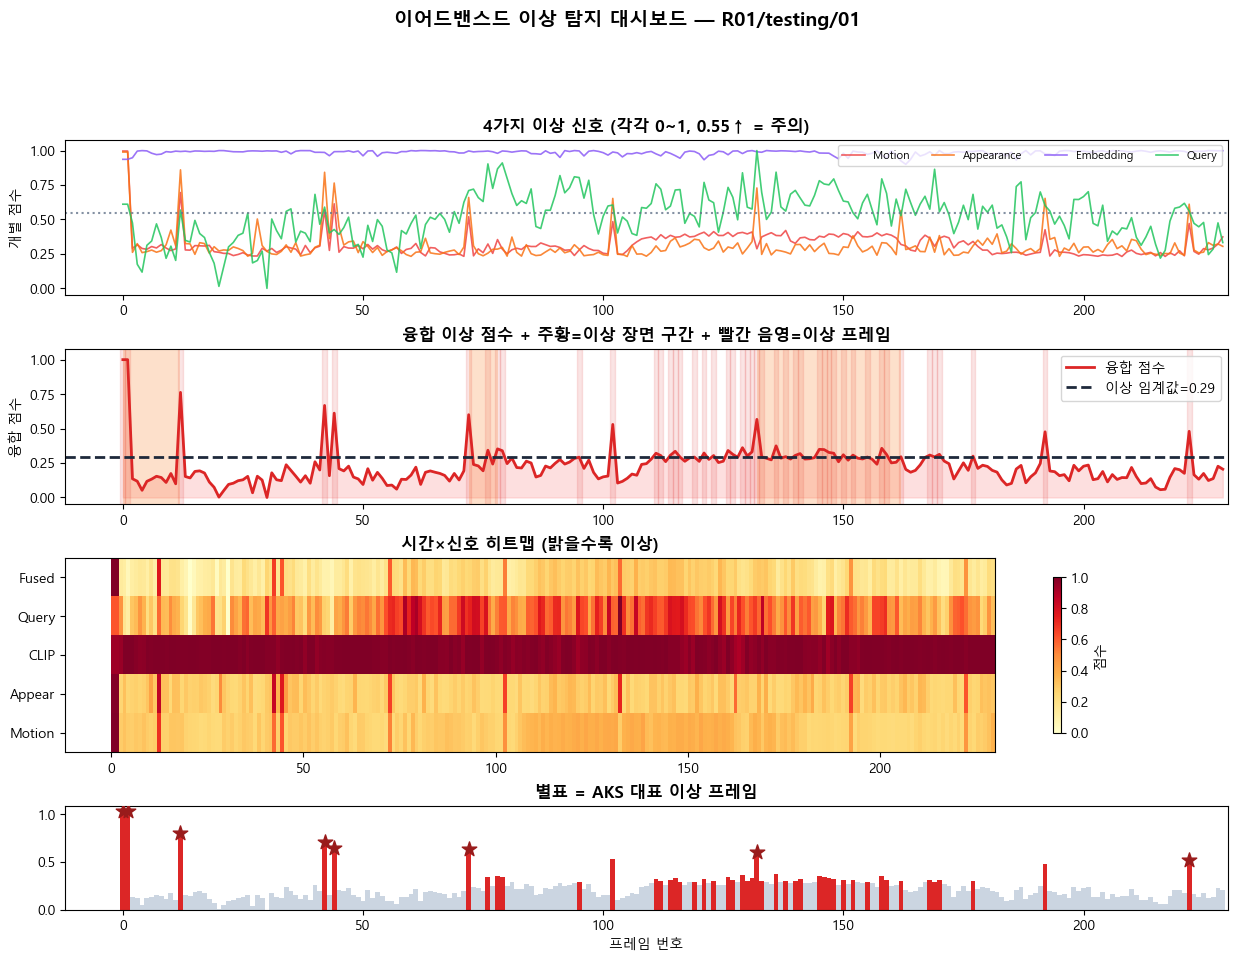

In [11]:
# --- 이상 탐지 종합 대시보드 (4신호 + 융합 + 히트맵 + AKS) ---
def plot_anomaly_overview(
    fused: np.ndarray,
    segments: list[VideoSegment],
    anomaly_scenes: list[VideoSegment],
    anomaly_frames: list[int],
    labels: np.ndarray | None,
    anomaly_mask: np.ndarray,
    fused_threshold: float,
    save_path: Path,
) -> None:
    """4신호·융합·히트맵·AKS를 한 화면에 모은 종합 대시보드."""
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(4, 1, height_ratios=[1.2, 1.2, 1.5, 0.8], hspace=0.35)  # 4행 레이아웃
    x = np.arange(len(fused))

    # ax0: 개별 4신호 (Motion/Appearance/Embedding/Query) 오버레이
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(MOTION_ANOMALY, color="#ef4444", lw=1.2, alpha=0.85, label="Motion")
    ax0.plot(APPEARANCE_ANOMALY, color="#f97316", lw=1.2, alpha=0.85, label="Appearance")
    ax0.plot(EMBEDDING_ANOMALY, color="#8b5cf6", lw=1.2, alpha=0.85, label="Embedding")
    ax0.plot(QUERY_ANOMALY, color="#22c55e", lw=1.2, alpha=0.85, label="Query")
    ax0.axhline(0.55, color="#64748b", ls=":", alpha=0.8)
    ax0.set_ylabel("개별 점수")
    ax0.set_title("4가지 이상 신호 (각각 0~1, 0.55↑ = 주의)", fontweight="bold")
    ax0.legend(loc="upper right", ncol=4, fontsize=8)
    ax0.set_ylim(-0.05, 1.08)

    # ax1: 융합 점수 + 이상 장면(주황) + 이상 프레임(빨간 음영) + GT(파란선)
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax1.fill_between(x, fused, alpha=0.35, color="#fca5a5")
    ax1.plot(fused, color="#dc2626", lw=2, label="융합 점수")
    ax1.axhline(fused_threshold, color="#1e293b", ls="--", lw=2,
                label=f"이상 임계값={fused_threshold:.2f}")
    for i in np.where(anomaly_mask)[0]:
        ax1.axvspan(i - 0.5, i + 0.5, color="#dc2626", alpha=0.12)
    for seg in anomaly_scenes:
        ax1.axvspan(seg.start, seg.end, alpha=0.22, color="#f97316", lw=0)
    if labels is not None and len(labels) >= len(fused):
        for i in np.where(labels[:len(fused)] > 0)[0]:
            ax1.axvline(i, color="#2563eb", alpha=0.35, lw=1.5)
    ax1.set_ylabel("융합 점수")
    ax1.set_title("융합 이상 점수 + 주황=이상 장면 구간 + 빨간 음영=이상 프레임", fontweight="bold")
    ax1.legend(loc="upper right")
    ax1.set_ylim(-0.05, 1.08)

    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    # 히트맵: 행=신호 종류, 열=시간(프레임)
    signal_matrix = np.vstack([
        MOTION_ANOMALY[:len(fused)],
        APPEARANCE_ANOMALY[:len(fused)],
        EMBEDDING_ANOMALY[:len(fused)],
        QUERY_ANOMALY[:len(fused)],
        fused,
    ])
    im = ax2.imshow(signal_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1,
                    extent=[0, len(fused), -0.5, 4.5], origin="lower")
    ax2.set_yticks([0, 1, 2, 3, 4])
    ax2.set_yticklabels(["Motion", "Appear", "CLIP", "Query", "Fused"])
    ax2.set_title("시간×신호 히트맵 (밝을수록 이상)", fontweight="bold")
    plt.colorbar(im, ax=ax2, label="점수", shrink=0.8)

    ax3 = fig.add_subplot(gs[3], sharex=ax0)
    bar_colors = np.where(anomaly_mask, "#dc2626", "#cbd5e1")
    ax3.bar(x, fused, color=bar_colors, width=1.0)
    for idx in anomaly_frames:
        ax3.scatter(idx, fused[idx] + 0.04, marker="*", s=120, color="#991b1b", zorder=5)
    ax3.set_xlabel("프레임 번호")
    ax3.set_title("별표 = AKS 대표 이상 프레임", fontweight="bold")

    fig.suptitle(
        f"이어드밴스드 이상 탐지 대시보드 — {TARGET_CLIP.device}/{TARGET_CLIP.split}/{TARGET_CLIP.clip_id}",
        fontsize=14, fontweight="bold", y=1.01,
    )
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_anomaly_overview(
    FUSED_SCORES, CP_SEGMENTS, ANOMALY_SCENES, ANOMALY_FRAME_IDX,
    FRAME_LABELS, ANOMALY_MASK, FUSED_THRESHOLD,
    FIG_DIR / "02_anomaly_overview.png",
)


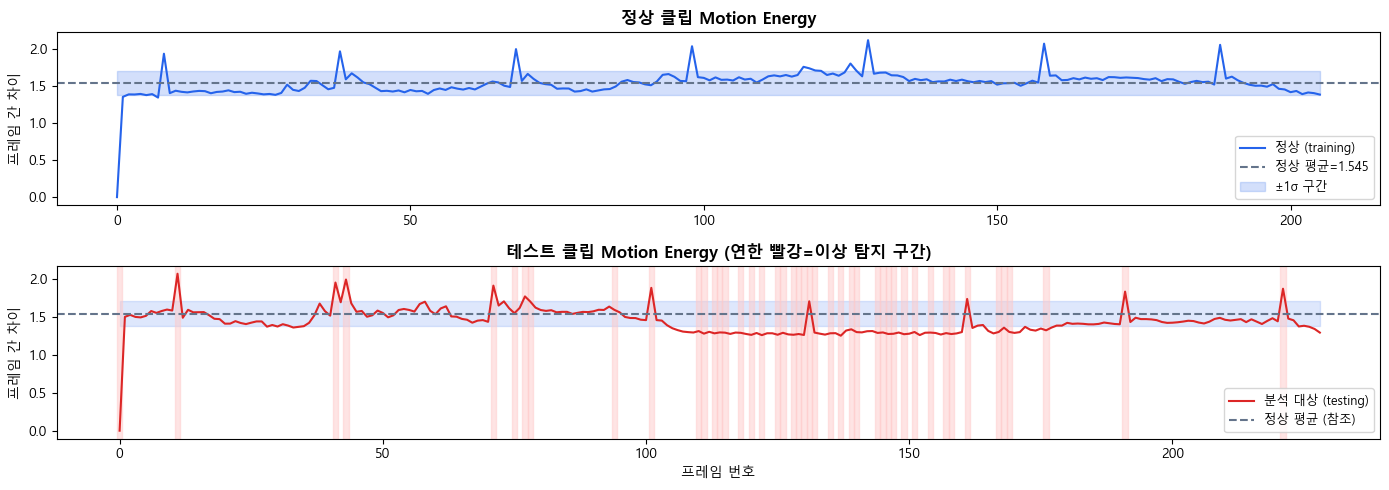

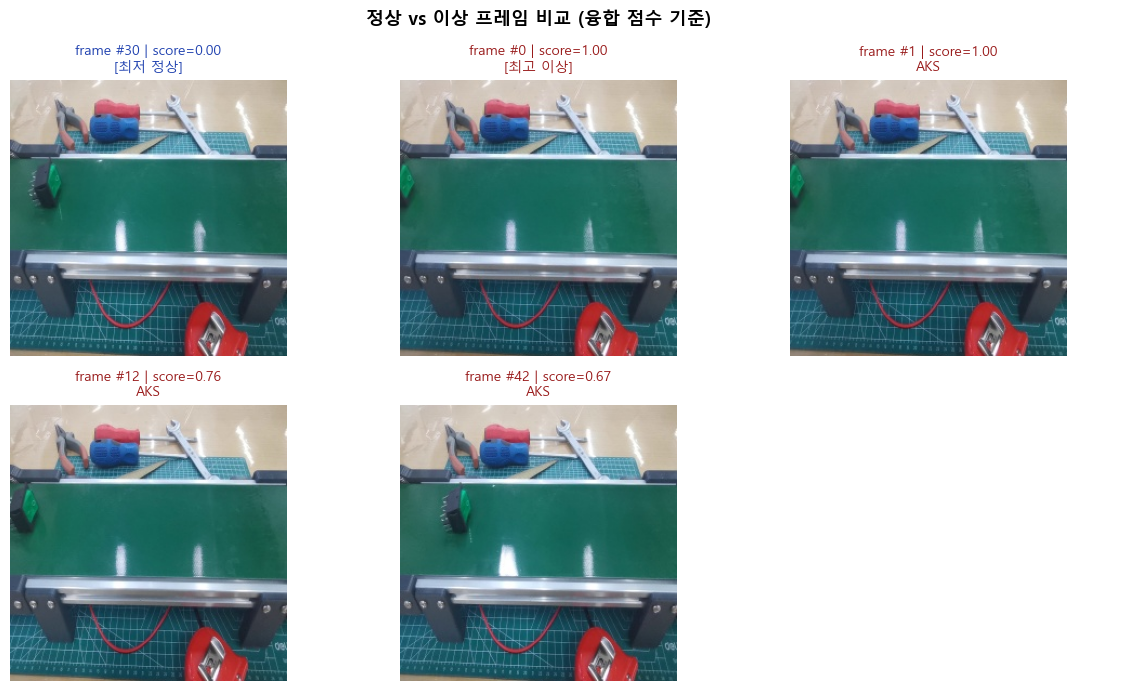

In [12]:
# --- 정상 vs 테스트 motion 비교 · 대표 프레임 갤러리 ---
def plot_train_vs_test_motion(save_path: Path) -> None:
    """training vs testing motion energy를 위·아래 subplot으로 비교."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)
    xt = np.arange(len(TARGET_MOTION))
    xr = np.arange(len(TRAIN_MOTION))

    axes[0].plot(xr, TRAIN_MOTION, color="#2563eb", lw=1.5, label="정상 (training)")
    axes[0].axhline(TRAIN_MU, color="#64748b", ls="--", label=f"정상 평균={TRAIN_MU:.3f}")
    axes[0].fill_between(xr, TRAIN_MU - TRAIN_SIGMA, TRAIN_MU + TRAIN_SIGMA,
                         alpha=0.2, color="#2563eb", label="±1σ 구간")
    axes[0].set_title("정상 클립 Motion Energy", fontweight="bold")
    axes[0].set_ylabel("프레임 간 차이")
    axes[0].legend(fontsize=9)

    axes[1].plot(xt, TARGET_MOTION, color="#dc2626", lw=1.5, label="분석 대상 (testing)")
    axes[1].axhline(TRAIN_MU, color="#64748b", ls="--", label="정상 평균 (참조)")
    axes[1].fill_between(xt, TRAIN_MU - TRAIN_SIGMA, TRAIN_MU + TRAIN_SIGMA,
                         alpha=0.15, color="#2563eb")
    # FUSED_SCORES[1:] ↔ motion 인덱스 정렬 (motion은 N-1 길이)
    for i in np.where(FUSED_SCORES[1 : len(xt) + 1] >= FUSED_THRESHOLD)[0]:
        axes[1].axvspan(i - 0.5, i + 0.5, color="#fecaca", alpha=0.5)
    axes[1].set_title("테스트 클립 Motion Energy (연한 빨강=이상 탐지 구간)", fontweight="bold")
    axes[1].set_xlabel("프레임 번호")
    axes[1].set_ylabel("프레임 간 차이")
    axes[1].legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


def plot_normal_vs_anomaly_frames(save_path: Path) -> None:
    """융합 점수 최저(정상)·최고(이상)·AKS 프레임 나란히 표시."""
    normal_idx = int(np.argmin(FUSED_SCORES))
    anomaly_idx = int(np.argmax(FUSED_SCORES))
    compare_idxs = [normal_idx, anomaly_idx] + ANOMALY_FRAME_IDX[:4]
    compare_idxs = list(dict.fromkeys(compare_idxs))[:6]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for ax, idx in zip(axes.flat, compare_idxs):
        ax.imshow(frame_to_rgb(TARGET_FRAMES[idx]))
        ax.axis("off")
        tag = "[최고 이상]" if idx == anomaly_idx else ("[최저 정상]" if idx == normal_idx else "AKS")
        ax.set_title(f"frame #{idx} | score={FUSED_SCORES[idx]:.2f}\n{tag}", fontsize=10,
                     color="#991b1b" if FUSED_SCORES[idx] >= FUSED_THRESHOLD else "#1e40af")
    for ax in axes.flat[len(compare_idxs):]:
        ax.axis("off")
    fig.suptitle("정상 vs 이상 프레임 비교 (융합 점수 기준)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


plot_train_vs_test_motion(FIG_DIR / "02b_train_vs_test_motion.png")
plot_normal_vs_anomaly_frames(FIG_DIR / "02c_normal_vs_anomaly_frames.png")


> **📖 Part 5 결과 해석 (초보자용)**
>
> ### 융합 점수란?
> Motion(30%) + Appearance(20%) + CLIP(35%) + Query(15%)를 **가중 합**한 최종 점수입니다.
>
> ### 그래프 읽기
> | 요소 | 의미 |
> |------|------|
> | **빨간 융합 곡선** | 프레임별 최종 이상 점수 |
> | **검은 점선** | 상위 20% 기준 임계값 — 이 위면 "이상" |
> | **주황 음영** | 이상 **장면(구간)** — 연속된 이상 구간 |
> | **히트맵** | 시간(가로) × 신호(세로), **밝을수록** 이상 |
> | **★ 별표** | 대표 이상 프레임 (AKS 선별) |
>
> ### 정상 vs 테스트 Motion 비교
> 파란 training 클립의 움직임 패턴과 testing 클립을 나란히 봅니다. testing에서 **파란 ±1σ 구간을 벗어나는 봉우리**가 이상 신호입니다.


## Part 6 — 통합 파이프라인 & VLM 이상 리포트

In [13]:
# =============================================================================
# 통합 파이프라인 — 전 단계 함수를 묶어 JSON·리포트 생성
# =============================================================================

@dataclass
class AnomalyDetectionResult:
    clip_id: str
    num_frames: int
    fusion_weights: dict[str, float]
    anomaly_scenes: list[dict]
    anomaly_frames: list[int]
    frame_scores: list[float]
    top_frame_indices: list[int]
    fused_threshold: float
    anomaly_frame_count: int
    text_report: str
    normal_query: str
    anomaly_query: str


_blip_model = None
_blip_processor = None


def get_blip_model():
    """BLIP 캡션 모델 lazy load (RUN_BLIP=True일 때)."""
    global _blip_model, _blip_processor
    if _blip_model is None and RUN_BLIP:
        from transformers import BlipForConditionalGeneration, BlipProcessor
        _blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_ID)
        _blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_ID).to(DEVICE).eval()
    return _blip_model, _blip_processor


@torch.inference_mode()
def caption_frame(frame_bgr: np.ndarray) -> str:
    model, processor = get_blip_model()
    if model is None:
        return "BLIP 비활성"
    image = Image.fromarray(frame_to_rgb(frame_bgr))
    inputs = processor(image, return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=40)
    return processor.decode(out[0], skip_special_tokens=True)


def build_anomaly_report(
    clip: IpadClip,
    scenes: list[VideoSegment],
    frame_indices: list[int],
    fused: np.ndarray,
    train_clip: IpadClip,
    fused_threshold: float,
    anomaly_mask: np.ndarray,
) -> str:
    """사람이 읽을 수 있는 텍스트 리포트 문자열 생성."""
    n_anom = int(anomaly_mask.sum())
    lines = [
        f"[Anomaly Scene Report] {clip.device}/{clip.split}/{clip.clip_id}",
        f"- 정상 baseline: {train_clip.device}/{train_clip.split}/{train_clip.clip_id}",
        f"- 전체 {len(fused)}프레임 | 이상 탐지 {n_anom}프레임 ({100*n_anom/len(fused):.1f}%)",
        f"- 융합 임계값: {fused_threshold:.3f} (상위 {100-ANOMALY_PERCENTILE:.0f}%)",
        f"- 융합 가중치: {FUSION_WEIGHTS}",
        f"- 이상 장면 후보: {len(scenes)}개",
    ]
    for i, seg in enumerate(scenes[:5], 1):
        t0, t1 = seg.start / FPS_ASSUMED, seg.end / FPS_ASSUMED
        lines.append(f"  장면{i}: {t0:.1f}s~{t1:.1f}s | score={seg.anomaly_score:.3f}")
    top3 = sorted(range(len(fused)), key=lambda i: fused[i], reverse=True)[:3]
    for rank, idx in enumerate(top3, 1):
        lines.append(f"  Top-{rank} frame #{idx} ({idx/FPS_ASSUMED:.1f}s) score={fused[idx]:.3f}")
    lines.append(f"- AKS 대표 프레임: {frame_indices}")
    return "\n".join(lines)


def run_anomaly_detection_pipeline(
    train_frames: list[np.ndarray],
    train_clip: IpadClip,
    target_frames: list[np.ndarray],
    target_clip: IpadClip,
    normal_query: str = NORMAL_QUERY,
    anomaly_query: str = ANOMALY_QUERY,
    num_frames: int = NUM_ANOMALY_FRAMES,
) -> AnomalyDetectionResult:
    """전 단계 함수를 순서대로 호출해 이상 탐지 결과 객체를 반환."""
    train_motion = compute_motion_energy(train_frames)
    target_motion = compute_motion_energy(target_frames)
    train_appearance = compute_appearance_change(train_frames)

    # 1) 4종 프레임 이상 신호
    centroid = build_normal_baseline(train_frames)
    motion_a = score_motion_anomaly(target_motion, train_motion)
    appearance_a = score_against_reference(
        compute_appearance_change(target_frames), train_appearance
    )
    embedding_a = score_embedding_anomaly(target_frames, centroid, train_frames)
    query_a = score_anomaly_query_contrast(target_frames, normal_query, anomaly_query)
    fused = fuse_anomaly_scores(motion_a, appearance_a, embedding_a, query_a)
    fused_thr = float(np.percentile(fused, ANOMALY_PERCENTILE))
    mask = fused >= fused_thr

    # 2) 세그멘테이션 · 장면/프레임 선별
    segments = segment_by_change_points(target_frames, target_motion)
    scenes = detect_anomaly_scenes(segments, fused)
    rep_frames = adaptive_keyframe_sampling(fused, num_frames, coverage_weight=0.3)
    top_frames = sorted(range(len(fused)), key=lambda i: fused[i], reverse=True)[:num_frames]

    report = build_anomaly_report(
        target_clip, scenes, rep_frames, fused, train_clip, fused_thr, mask
    )
    if RUN_BLIP and rep_frames:
        cap = caption_frame(target_frames[rep_frames[len(rep_frames) // 2]])
        report += f"\n- BLIP 캡션(대표 프레임): {cap}"

    return AnomalyDetectionResult(
        clip_id=f"{target_clip.device}_{target_clip.split}_{target_clip.clip_id}",
        num_frames=len(target_frames),
        fusion_weights=dict(FUSION_WEIGHTS),
        anomaly_scenes=[
            {"start": s.start, "end": s.end, "score": round(s.anomaly_score, 4),
             "time_sec": [round(s.start / FPS_ASSUMED, 2), round(s.end / FPS_ASSUMED, 2)]}
            for s in scenes
        ],
        anomaly_frames=rep_frames,
        frame_scores=[round(float(x), 4) for x in fused],
        top_frame_indices=top_frames,
        fused_threshold=round(fused_thr, 4),
        anomaly_frame_count=int(mask.sum()),
        text_report=report,
        normal_query=normal_query,
        anomaly_query=anomaly_query,
    )


# 전체 파이프라인 1회 실행
anomaly_result = run_anomaly_detection_pipeline(
    TRAIN_FRAMES, TRAIN_CLIP, TARGET_FRAMES, TARGET_CLIP
)
print(anomaly_result.text_report)


[Anomaly Scene Report] R01/testing/01
- 정상 baseline: R01/training/01
- 전체 230프레임 | 이상 탐지 46프레임 (20.0%)
- 융합 임계값: 0.292 (상위 20%)
- 융합 가중치: {'motion': 0.3, 'appearance': 0.2, 'embedding': 0.35, 'query': 0.15}
- 이상 장면 후보: 3개
  장면1: 0.0s~0.4s | score=0.562
  장면2: 2.4s~2.6s | score=0.425
  장면3: 4.4s~5.4s | score=0.410
  Top-1 frame #0 (0.0s) score=1.000
  Top-2 frame #1 (0.0s) score=1.000
  Top-3 frame #12 (0.4s) score=0.763
- AKS 대표 프레임: [0, 1, 12, 42, 44, 72, 132, 222]


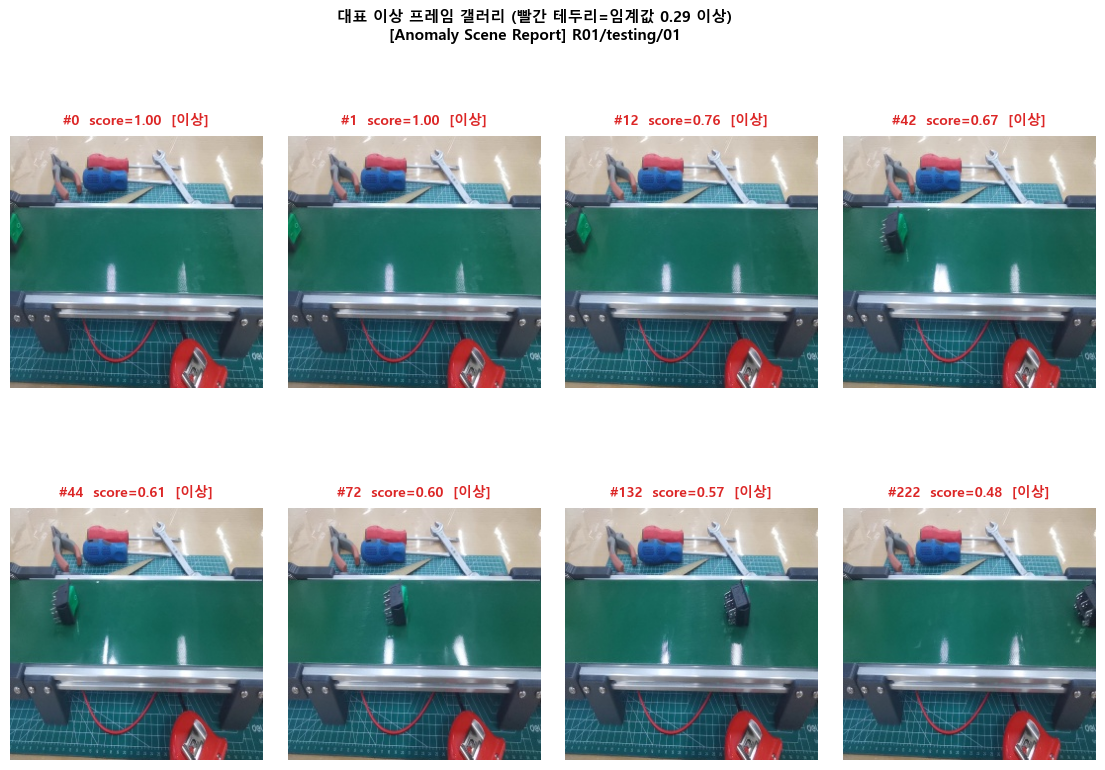

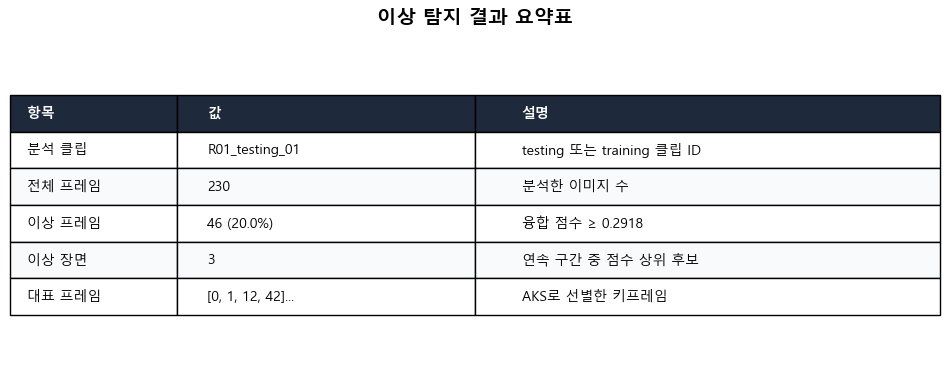

Manifest 저장: output_anomaly_scene\anomaly_manifest.json
저장된 그래프: C:\MyCursorLab\08_Video AI 처리 및 분석\output_anomaly_scene\figures


In [14]:
# --- 결과물 export · 갤러리 · 요약표 ---
def export_anomaly_artifacts(result: AnomalyDetectionResult, frames: list[np.ndarray]) -> Path:
    """대표 프레임 JPG, 장면 mid-frame, anomaly_manifest.json 저장."""
    clip_dir = ANOMALY_DIR / result.clip_id
    clip_dir.mkdir(parents=True, exist_ok=True)
    for i, idx in enumerate(result.anomaly_frames):
        out = clip_dir / f"anomaly_{i:02d}_f{idx:04d}.jpg"
        imwrite_bgr(out, frames[idx])

    scene_payload = []
    for si, scene in enumerate(result.anomaly_scenes):
        sdir = SCENE_DIR / result.clip_id / f"scene_{si:02d}"
        sdir.mkdir(parents=True, exist_ok=True)
        mid = (scene["start"] + scene["end"]) // 2
        imwrite_bgr(sdir / f"mid_f{mid:04d}.jpg", frames[mid])
        scene_payload.append({**scene, "mid_frame": mid, "export_dir": str(sdir)})

    payload = {
        "clip_id": result.clip_id,
        "normal_query": result.normal_query,
        "anomaly_query": result.anomaly_query,
        "fusion_weights": result.fusion_weights,
        "fused_threshold": result.fused_threshold,
        "anomaly_frame_count": result.anomaly_frame_count,
        "num_frames": result.num_frames,
        "anomaly_scenes": scene_payload,
        "anomaly_frames": result.anomaly_frames,
        "top_frame_indices": result.top_frame_indices,
        "text_report": result.text_report,
    }
    MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return MANIFEST_PATH


def plot_anomaly_input_card(result: AnomalyDetectionResult, frames: list[np.ndarray],
                            fused: np.ndarray, threshold: float, save_path: Path) -> None:
    """AKS 대표 프레임 갤러리 — 테두리 색·[이상]/[정상] 텍스트로 판정 표시."""
    idxs = result.anomaly_frames
    n = len(idxs)
    cols = min(4, n)
    rows = int(np.ceil(n / cols)) if n else 1
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows + 0.9))
    axes = np.atleast_2d(axes)
    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n:
            idx = idxs[i]
            ax.imshow(frame_to_rgb(frames[idx]))
            score = fused[idx]
            is_anom = score >= threshold
            border_color = "#dc2626" if is_anom else "#94a3b8"
            status = "[이상]" if is_anom else "[정상]"  # 임계값 기준 판정
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color(border_color)
                spine.set_linewidth(4)
            ax.set_title(
                f"#{idx}  score={score:.2f}  {status}",
                fontsize=10, color=border_color, fontweight="bold", pad=8,
            )
    fig.suptitle(
        f"대표 이상 프레임 갤러리 (빨간 테두리=임계값 {threshold:.2f} 이상)\n"
        + result.text_report.split("\n")[0],
        fontsize=11, fontweight="bold", y=1.02,
    )
    plt.subplots_adjust(top=0.90, hspace=0.18, wspace=0.10, bottom=0.03)
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


def plot_detection_summary_table(result: AnomalyDetectionResult, save_path: Path) -> None:
    """탐지 결과를 표 형태로 요약 시각화."""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [
        ["항목", "값", "설명"],
        ["분석 클립", result.clip_id, "testing 또는 training 클립 ID"],
        ["전체 프레임", str(result.num_frames), "분석한 이미지 수"],
        ["이상 프레임", f"{result.anomaly_frame_count} ({100*result.anomaly_frame_count/result.num_frames:.1f}%)",
         f"융합 점수 ≥ {result.fused_threshold}"],
        ["이상 장면", str(len(result.anomaly_scenes)), "연속 구간 중 점수 상위 후보"],
        ["대표 프레임", str(result.anomaly_frames[:4]) + "...", "AKS로 선별한 키프레임"],
    ]
    table = ax.table(cellText=rows, loc="center", cellLoc="left", colWidths=[0.18, 0.32, 0.5])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)
    for j in range(3):
        table[(0, j)].set_facecolor("#1e293b")
        table[(0, j)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(rows)):
        if i % 2 == 0:
            for j in range(3):
                table[(i, j)].set_facecolor("#f8fafc")
    ax.set_title("이상 탐지 결과 요약표", fontsize=14, fontweight="bold", pad=20)
    fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()


# JPG·JSON export 후 갤러리·요약표 PNG 생성
manifest_path = export_anomaly_artifacts(anomaly_result, TARGET_FRAMES)
plot_anomaly_input_card(
    anomaly_result, TARGET_FRAMES, FUSED_SCORES, FUSED_THRESHOLD,
    FIG_DIR / "03_anomaly_input_card.png",
)
plot_detection_summary_table(anomaly_result, FIG_DIR / "04_detection_summary.png")
print(f"Manifest 저장: {manifest_path}")
print(f"저장된 그래프: {FIG_DIR.resolve()}")


> **📖 Part 6 결과 해석 (초보자용)**
>
> ### 저장된 산출물
> | 폴더/파일 | 설명 |
> |-----------|------|
> | `output_anomaly_scene/figures/` | 8장의 분석 그래프 |
> | `anomaly_frames/` | AKS로 뽑은 대표 이상 프레임 JPG |
> | `anomaly_scenes/` | 이상 장면별 중간 프레임 JPG |
> | `anomaly_manifest.json` | 점수·구간·프레임 목록 (프로그램 연동용) |
>
> ### 갤러리 그래프 읽기
> - **빨간 테두리** = 융합 점수가 임계값 이상 → **이상으로 판정**
> - **요약표** = 전체 프레임 중 몇 %가 이상인지 한눈에 확인
>
> 💡 실무에서는 `anomaly_manifest.json`의 `anomaly_scenes` 시간 구간을 알람 시스템에 연결하면 됩니다.


# 전체 요약 & 초보자 가이드

## 한눈에 보는 파이프라인

```
IPAD 정상 클립 (training)
        ↓ baseline 구축
┌───────────────────────────────────────┐
│  Motion │ Appearance │ CLIP │ Query   │  ← 4가지 이상 신호
└───────────────────────────────────────┘
        ↓ 가중 융합 (30+20+35+15%)
   융합 점수 + Change-point 세그멘테이션
        ↓
   이상 장면 구간 + AKS 대표 프레임
        ↓
   anomaly_manifest.json + 그래프 저장
```

## 단계별 비교 (04 vs 05)

| 단계 | 04 비디오 요약 | 05 이상 장면 탐지 |
|------|---------------|------------------|
| Baseline | 전체 프레임 relevance | **정상 training centroid** |
| 선별 목적 | 요약용 대표 프레임 | **이상 점수 상위 프레임·구간** |
| CLIP 역할 | 단일 summary query | **정상 vs 이상 query contrast** |
| 세그멘테이션 | narrative 구간 | **anomaly score 상위 장면** |
| 산출물 | summary_manifest.json | **anomaly_manifest.json** |

## 생성된 파일 안내

| 파일 | 내용 |
|------|------|
| `01_frame_anomaly_signals.png` | Motion·Appearance 프레임 점수 |
| `01b_embedding_anomaly.png` | CLIP 임베딩 편차 bar chart |
| `01c_query_contrast.png` | VLM 텍스트 쿼리 대조 |
| `02_anomaly_overview.png` | 4-in-1 통합 대시보드 + 히트맵 |
| `02b_train_vs_test_motion.png` | 정상 vs 테스트 움직임 비교 |
| `02c_normal_vs_anomaly_frames.png` | 정상·이상 프레임 나란히 |
| `03_anomaly_input_card.png` | 대표 이상 프레임 갤러리 |
| `04_detection_summary.png` | 결과 요약표 |
| `output_anomaly_scene/anomaly_manifest.json` | JSON 결과 (프레임·구간·점수) |

## 자주 묻는 질문 (FAQ)

**Q. 이상이 잘 안 보여요.**  
A. `ANOMALY_PERCENTILE`을 75로 낮추면 더 많은 프레임이 이상으로 표시됩니다. `FUSION_WEIGHTS`에서 CLIP 비중을 높여보세요.

**Q. 빨간 음영(GT)과 우리 결과가 다릅니다.**  
A. GT 라벨은 사람이标注한 정답이고, 우리는 **무지도**로 탐지합니다. 완벽히 일치하지 않아도 일부 구간이 겹치면 성공입니다.

**Q. testing 클립을 바꾸고 싶어요.**  
A. `SELECTED_TEST_CLIP = "02"` 처럼 클립 ID를 지정하세요.

### 확장 실습 아이디어
- `FUSION_WEIGHTS` 조정 후 GT 라벨(`frame_labels_*.npy`)과 Precision/Recall 비교
- `ANOMALY_QUERY`를 설비별 고장 유형 문장으로 교체 (예: stuck, leak, vibration)
- `RUN_BLIP=True`로 이상 프레임 자동 캡션 생성 후 VLM 리포트 보강
- 02번 temporal pattern (DTW, Mahalanobis) 점수를 `fuse_anomaly_scores`에 추가

### 참고
- Liu et al., *IPAD: Industrial Process Anomaly Detection Dataset*, arXiv:2404.15033
- 04번: VLM 기반 비디오 요약 — 선별·토큰 압축 파이프라인
